This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - always picking 5 tasks. 

In [18]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# start with some U_true, in this simulation its 5 tasks x 5 parcels

In [19]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [20]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [21]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

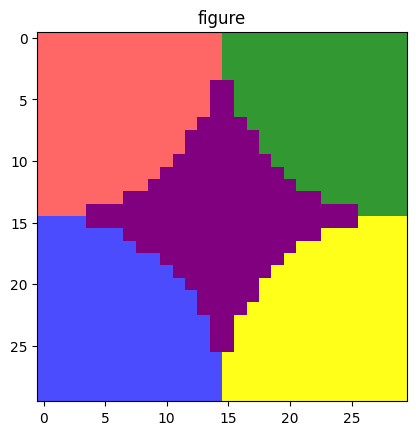

In [22]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

In [23]:
if type(U_true_5) == pt.Tensor:
    U_true_5 = U_true_5.numpy()

print(type(U_true_5))

if U_true_5.ndim == 2:
    U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])

print(U_true_5.shape)

<class 'numpy.ndarray'>
(1, 5, 900)


# Make a random task battery with 30 task and plot second moment matrix

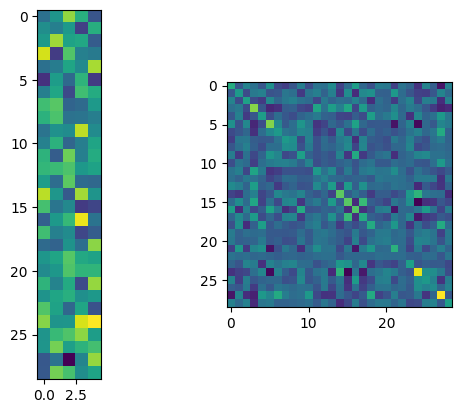

In [24]:
num_task_lib = 29
rng= np.random.default_rng(seed=4)
V_lib = rng.normal(0,1,(num_task_lib, K_main))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

In [25]:
Y_true = V_lib @ np.array(U_true_5[0])
vtest = V_lib
ytest = Y_true


In [26]:
# try and evaluate random combinations of these task 
noise = 0.4

D = ut.build_combinations(G_lib, strategy='random', n_iter=1000, n_tasks=6, seed=2, replacement=True)
# Try the classification of the region voxels
D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, V_lib, U_true_5, sig_e=noise, vtest=vtest, ytest=ytest)
#reset indices of D_ev
D_ev = D_ev.reset_index(drop=True)

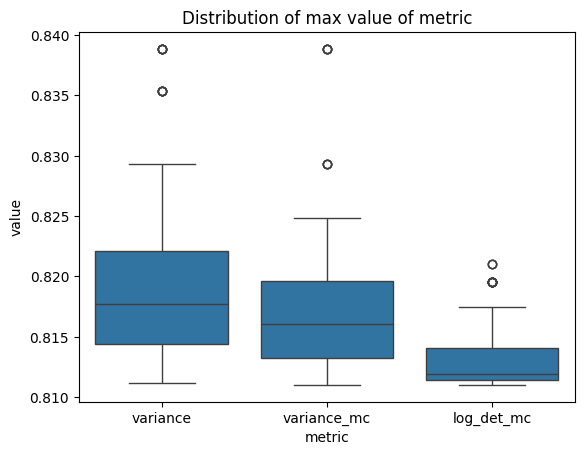

In [27]:
num_batteries = 100
num_iterations = 100
eval_metric = 'cos'
output_df = ut.max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)
output_long = output_df.melt(var_name="metric", value_name="value")

# only keep 3 metrics
metrics = ['variance','variance_mc','log_det_mc']
output_long = output_long[output_long['metric'].isin(metrics)]

# group by metric and plot
plt.figure()
sns.boxplot(x='metric', y='value', data=output_long)
plt.title('Distribution of max value of metric')
plt.show()


# Does the usefullness of the eigenmetrics change with changing the number of tasks?

In [42]:
# 2 to 24 steps of 2
battery_sizes = [4,6,8,10,14,18,22]
noise = 1

In [43]:
results_list = []

for i in battery_sizes:
    print(f"Processing battery size: {i}")
    
    # Generate task combinations and evaluate
    D = ut.build_combinations(G_lib, strategy='random', n_iter=5000, n_tasks=i, seed=2, replacement=True)
    D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, V_lib, U_true_5, sig_e=noise, vtest=vtest, ytest=ytest)
    D_ev = D_ev.reset_index(drop=True)
    
    # Perform max value distribution analysis
    num_batteries = 2000
    num_iterations = 100
    eval_metric = 'cos'
    output_df = ut.max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)
    output_long = output_df.melt(var_name="metric", value_name="value")
    
    output_long["battery_size"] = i
    
    results_list.append(output_long)

results_df = pd.concat(results_list, ignore_index=True)

Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 10
Processing battery size: 14
Processing battery size: 18
Processing battery size: 22


In [44]:
#include only rows with metric  = 'variance' or 'variance_mc' or 'log_det_mc' nad change the metric name to 'variance',' Mean Centered Variance' and 'Log Determinant'
results_df = results_df.loc[results_df['metric'].isin(['variance','variance_mc','log_det_mc'])]
results_df['metric'] = results_df['metric'].replace({'variance':'Variance','variance_mc':'Mean Centered Variance','log_det_mc':'Log Determinant'})


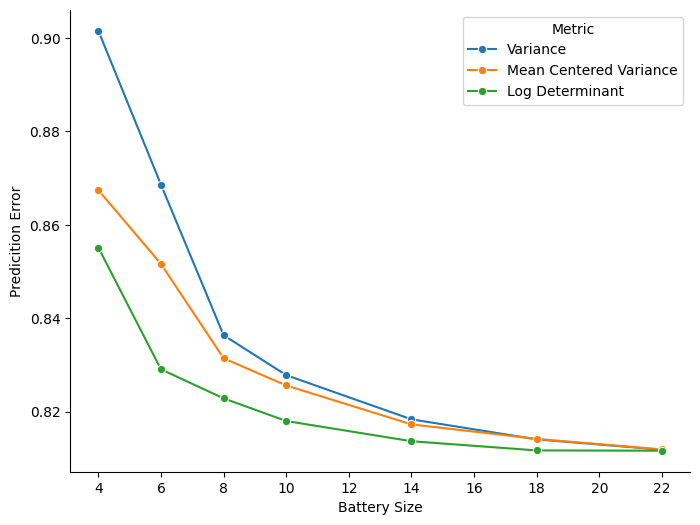

In [49]:

agg_df = results_df.groupby(["battery_size", "metric"], as_index=False).agg(
    mean_value=("value", "mean")
)

palette = sns.color_palette("tab10", n_colors=agg_df["metric"].nunique())

plt.figure(figsize=(8, 6))

sns.lineplot(
    data=results_df,
    x="battery_size",
    y="value",
    hue="metric",
    marker="o",
    palette=palette,
    errorbar=None 
)

xticks = np.arange(4, 24, 2)
plt.xticks(xticks)

plt.xlabel("Battery Size")
plt.ylabel("Predicition Error")
plt.legend(title="Metric")
sns.despine()


plt.show()

